<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()

X = data.data
y = data.target

print(data.feature_names)
print(data.target_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Criar o modelo
model = DecisionTreeClassifier(random_state=42)

# Treinar
model.fit(X_train, y_train)

# Previsões
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Acurácia
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Acurácia no treino:", train_acc)
print("Acurácia no teste:", test_acc)

Acurácia no treino: 1.0
Acurácia no teste: 0.9333333333333333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

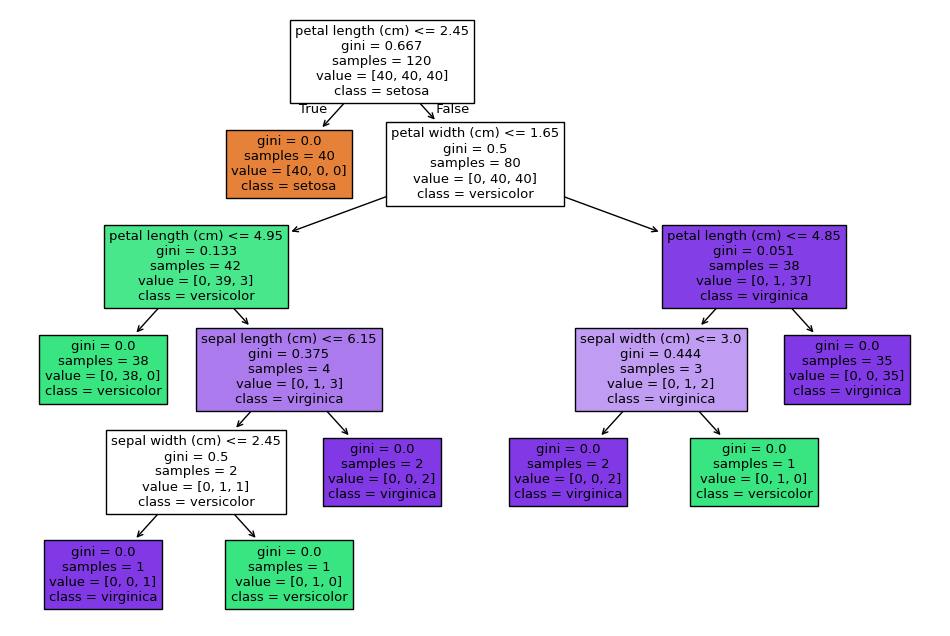

In [35]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True
)

plt.show()

**Adicione seu texto de solução aqui**.

O atributo da raiz é petal_length.
A profundidade da árvore é 5.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [37]:
import pandas as pd

resultados = []

# Lista de profundidades
profundidades = list(range(1, 10)) + [None]

for depth in profundidades:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    # Treinar
    model.fit(X_train, y_train)
    
    # Previsões
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Métricas
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # Informações da árvore
    profundidade_real = model.get_depth()
    folhas = model.get_n_leaves()
    
    # Guardar resultados
    resultados.append({
        "max_depth": depth,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "depth_real": profundidade_real,
        "n_leaves": folhas
    })

# Criar tabela
df = pd.DataFrame(resultados)

print(df)

   max_depth  train_acc  test_acc  depth_real  n_leaves
0        1.0   0.666667  0.666667           1         2
1        2.0   0.966667  0.933333           2         3
2        3.0   0.983333  0.966667           3         5
3        4.0   0.991667  0.933333           4         7
4        5.0   1.000000  0.933333           5         8
5        6.0   1.000000  0.933333           5         8
6        7.0   1.000000  0.933333           5         8
7        8.0   1.000000  0.933333           5         8
8        9.0   1.000000  0.933333           5         8
9        NaN   1.000000  0.933333           5         8


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [38]:
resultados = []

criterios = ["gini", "entropy"]

for c in criterios:
    model = DecisionTreeClassifier(criterion=c, random_state=42)
    
    # Treinar
    model.fit(X_train, y_train)
    
    # Previsões
    y_pred = model.predict(X_test)
    
    # Métricas
    acc = accuracy_score(y_test, y_pred)
    depth = model.get_depth()
    
    resultados.append({
        "criterion": c,
        "accuracy_test": acc,
        "depth": depth
    })

# Mostrar resultados
import pandas as pd
df = pd.DataFrame(resultados)
print(df)

  criterion  accuracy_test  depth
0      gini       0.933333      5
1   entropy       0.933333      5


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [39]:
resultados = []

for depth in range(1, 11):  # testando de 1 a 10
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    resultados.append({
        "max_depth": depth,
        "train_acc": accuracy_score(y_train, y_train_pred),
        "test_acc": accuracy_score(y_test, y_test_pred)
    })

df = pd.DataFrame(resultados)
print(df)

   max_depth  train_acc  test_acc
0          1   0.666667  0.666667
1          2   0.966667  0.933333
2          3   0.983333  0.966667
3          4   0.991667  0.933333
4          5   1.000000  0.933333
5          6   1.000000  0.933333
6          7   1.000000  0.933333
7          8   1.000000  0.933333
8          9   1.000000  0.933333
9         10   1.000000  0.933333


Foi analisado o impacto do hiperparâmetro max_depth no desempenho da árvore de decisão. Observou-se que, para valores baixos (como 1), o modelo apresenta underfitting, com baixa acurácia tanto no treino quanto no teste. À medida que a profundidade aumenta, a acurácia melhora, atingindo seu melhor desempenho com max_depth = 3.

Para valores maiores, o modelo passa a apresentar overfitting, com acurácia perfeita no treino (1.0), mas sem melhoria no conjunto de teste, que permanece em torno de 93%.

O melhor modelo encontrado foi com max_depth = 3, obtendo acurácia de aproximadamente 96,7% no teste, representando o melhor equilíbrio entre viés e variância.